# Python Refresher for Data Science

## 1. Why Choose Python for Data Science
- Easy to learn and read
- Rich ecosystem: NumPy, Pandas, Scikit-learn, TensorFlow
- Strong community support

---

## 2. Variables, Data Types, Typecasting
```python
a = 10        # integer
b = 3.14      # float
c = "Data"    # string
print(type(a), type(b), type(c))

# Typecasting
num_str = "25"
num_int = int(num_str)
print(num_int + 5)


In [14]:
text = "Data Science"
print(text.upper())
print(text.lower())
print(text.split())


DATA SCIENCE
data science
['Data', 'Science']


In [15]:
x = 5
y = 2
print(x + y, x - y, x * y, x / y)

# Input example
# name = input("Enter your name: ")
# print(f"Hello {name}")


7 3 10 2.5


In [16]:
def check_number(n):
    if n > 0:
        return "Positive"
    elif n < 0:
        return "Negative"
    else:
        return "Zero"

print(check_number(10))


Positive


In [17]:
status = "success"
match status:
    case "success":
        print("Operation successful")
    case "error":
        print("Operation failed")


Operation successful


In [18]:
# Lists
nums = [1, 2, 3, 4]
for n in nums:
    print(n**2)

# Tuples
t = (1, 2, 3)
print(t[0])

# Sets
s = {1, 2, 2, 3}
print(s)

# Dictionaries
d = {"name": "Shivam", "role": "Data Intern"}
print(d["name"])


1
4
9
16
1
{1, 2, 3}
Shivam


In [19]:
# File Handling
with open("sample.txt", "w") as f:
    f.write("Hello Data Science")

# JSON
import json
data = {"name": "Shivam", "skills": ["Python", "SQL"]}
json_str = json.dumps(data)
print(json_str)


{"name": "Shivam", "skills": ["Python", "SQL"]}


In [20]:
class Student:
    def __init__(self, name):
        self.name = name

    def greet(self):
        return f"Hello, I am {self.name}"

s1 = Student("Shivam")
print(s1.greet())


Hello, I am Shivam


In [21]:
# List comprehension
squares = [x**2 for x in range(5)]
print(squares)

# Lambda
double = lambda x: x * 2
print(double(10))


[0, 1, 4, 9, 16]
20


# Part 3: Data Visualization (Matplotlib & Seaborn)
Visualization helps uncover patterns and outliers in your data. 
* **Matplotlib:** The foundational library for detailed, customizable plots.
* **Seaborn:** Built on Matplotlib, it provides beautiful default styles and high-level statistical graphs.

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Apply a professional Seaborn theme to all plots
sns.set_theme(style="whitegrid")

# Create a sample dataset for visualization
data = {
    'Department': ['Data', 'Web3', 'AI', 'Design', 'Data', 'AI', 'Engineering'],
    'Projects_Completed': [12, 5, 8, 15, 20, 10, 25],
    'Connections': [15, 120, 45, 80, 12, 65, 340],
    'Satisfaction_Score': [4.5, 3.8, 4.2, 4.8, 3.5, 4.0, 4.9]
}
df_viz = pd.DataFrame(data)

display(df_viz.head())

,Department,Projects_Completed,Connections,Satisfaction_Score
0,Data,12,15,4.5
1,Web3,5,120,3.8
2,AI,8,45,4.2
3,Design,15,80,4.8
4,Data,20,12,3.5


## 1. Core Charts: Bar, Pie, and Scatter
* **Bar Charts:** Compare categorical data.
* **Pie Charts:** Show proportions.
* **Scatter Plots:** Discover correlations between two continuous variables.

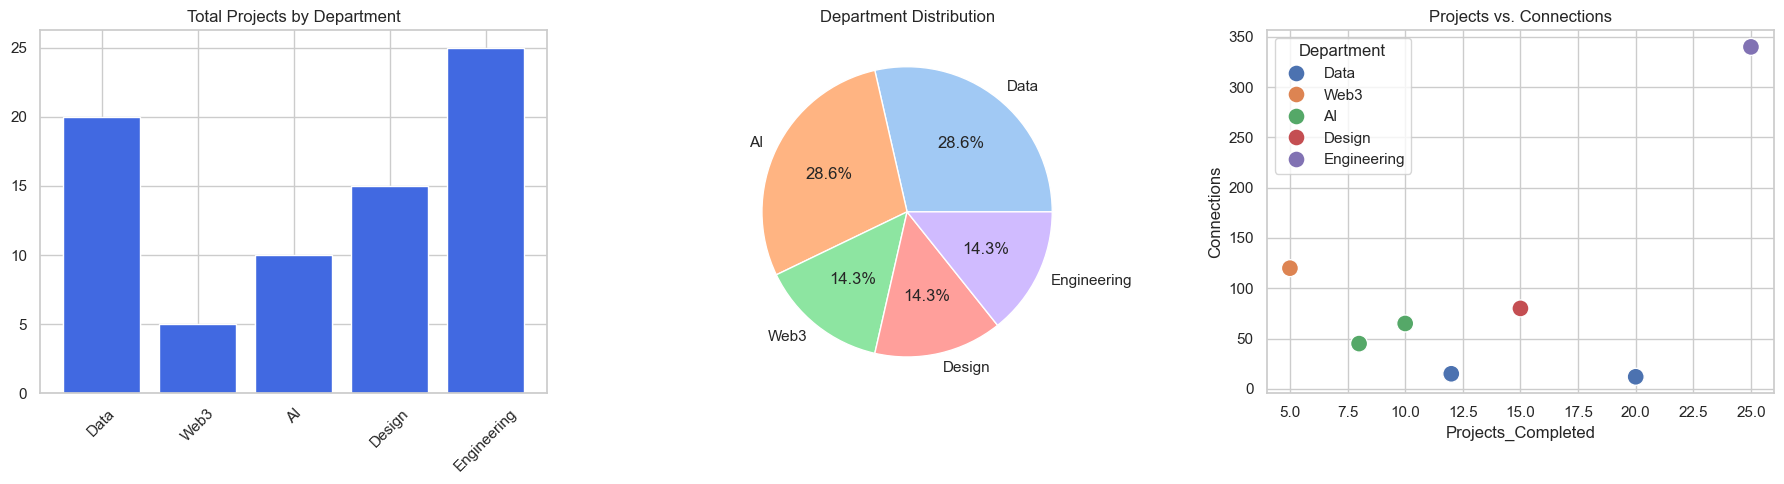

In [23]:
# Create a figure with multiple subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Bar Chart (Matplotlib)
axes[0].bar(df_viz['Department'], df_viz['Projects_Completed'], color='royalblue')
axes[0].set_title('Total Projects by Department')
axes[0].tick_params(axis='x', rotation=45)

# 2. Pie Chart (Matplotlib)
dept_counts = df_viz['Department'].value_counts()
axes[1].pie(dept_counts, labels=dept_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[1].set_title('Department Distribution')

# 3. Scatter Plot (Seaborn)
sns.scatterplot(data=df_viz, x='Projects_Completed', y='Connections', hue='Department', s=150, ax=axes[2])
axes[2].set_title('Projects vs. Connections')

plt.tight_layout()
plt.show()

## 2. Statistical Distributions
Histograms and Boxplots are essential for understanding data spread and finding outliers.

C:\Users\shiva\AppData\Local\Temp\ipykernel_26088\222211581.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Department', y='Satisfaction_Score', data=df_viz, palette='Set2', ax=ax2)


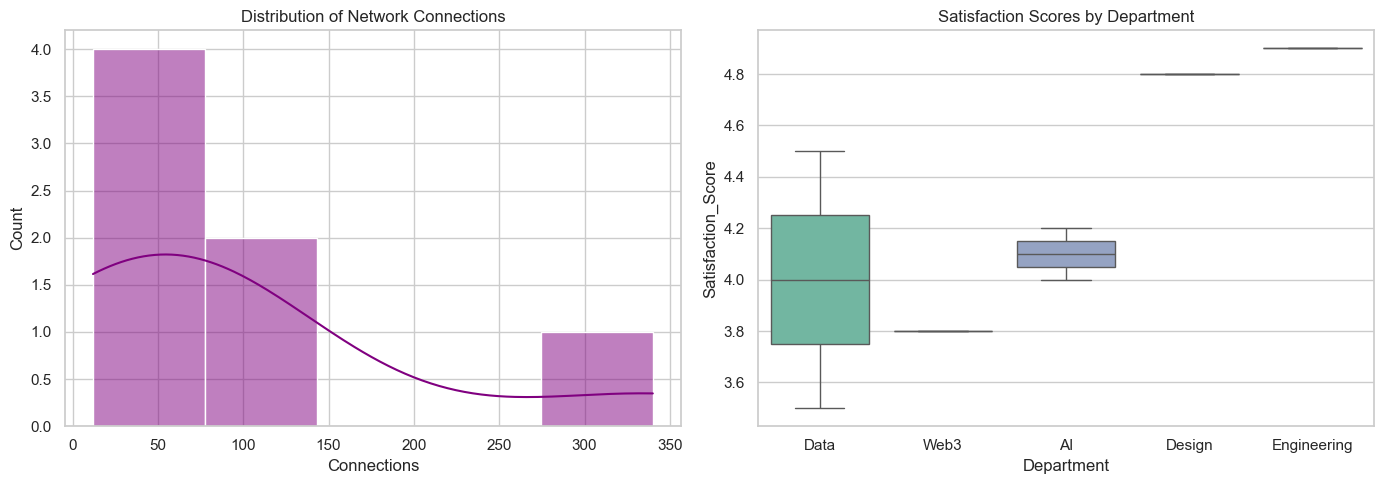

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE (Kernel Density Estimate)
sns.histplot(df_viz['Connections'], bins=5, kde=True, color='purple', ax=ax1)
ax1.set_title('Distribution of Network Connections')

# Boxplot for Outlier Detection
sns.boxplot(x='Department', y='Satisfaction_Score', data=df_viz, palette='Set2', ax=ax2)
ax2.set_title('Satisfaction Scores by Department')

plt.tight_layout()
plt.show()

# Part 4: Data Collection via Web Scraping
When APIs or CSVs aren't available, we extract data directly from website HTML using `requests` and `BeautifulSoup`.

In [25]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://en.wikipedia.org/wiki/List_of_programming_languages"

# 1. Create a dictionary with a standard browser User-Agent
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

# 2. Pass the headers into the get() request
response = requests.get(url, headers=headers)

# 3. Check if successful, then parse
if response.status_code == 200:
    print("✅ Successfully fetched the webpage!\n")
    soup = BeautifulSoup(response.text, 'html.parser')
    
    columns = soup.find_all('div', class_='div-col')
    languages = []
    
    if columns:
        for col in columns:
            items = col.find_all('li')
            for item in items:
                languages.append(item.text.strip())
                
        df_languages = pd.DataFrame(languages, columns=['Programming Language'])
        
        print(f"Scraped {len(df_languages)} languages. Here are the first 10:")
        display(df_languages.head(10))
    else:
        print("Could not find the target columns on the page.")
        
else:
    print(f"❌ Failed to fetch page. Status Code: {response.status_code}")

✅ Successfully fetched the webpage!

Scraped 676 languages. Here are the first 10:


,Programming Language
0,A.NET (A#/A sharp)
1,A-0 System
2,A+ (A plus)
3,ABAP
4,ABC
5,ACC
6,Accent (Rational Synergy)
7,Action!
8,ActionScript
9,Actor
